# 03 - Deep Learning Multimodal: Late Fusion + SAE doble + ViT central + GRU

**Versión:** v11 — Fix `sparsity_txt` gate (único FAIL restante de v10)

## Diagnóstico del FAIL en v8/v9

`cos_sim_txt` se atascaba en ~0.925 desde epoch 15 en adelante. La causa raíz tiene **dos capas**:

### Capa 1 — Problema estructural (por qué 0.925 es esperado sin fix)
GeoRSCLIP produce embeddings de texto muy similares entre sí para captions que describen la misma zona geográfica con variaciones menores (misma ciudad, mismo tipo de contaminante, mismo rango de magnitud). El texto encoder, frozen, aplana el espacio semántico: `cos_sim` entre cualquier par de captions sobre Cali oscila entre 0.85–0.96 incluso antes del SAE. El SAE_txt reconstruye fielmente → preserva esa alta similitud. **Resultado: `cos_sim_txt` ≈ 0.93 sin importar cuánto entrenes.**

### Capa 2 — Falta de presión de diversificación en la loss SAE_txt
La loss del SAE_txt en v8/v9 era solo `MSE_recon + λ * L1`. No hay ningún término que penalice explícitamente que los embeddings reconstruidos sean parecidos entre sí. El optimizador no tiene incentivo para separar las representaciones.

## Fix v10: tres cambios quirúrgicos

1. **InfoNCE contrastivo sobre `emb_txt_recon`** (`W_CONTRASTIVE_TXT = 0.5`): penaliza que pares negativos (distinto `tile_id`) sean similares. Esto añade gradiente que empuja las reconstrucciones a separarse en el espacio. Temperatura learnable `τ` inicializada en `log(1/0.07)`.

2. **Normalización de `emb_txt_recon` antes del InfoNCE**: el SAE decoder no normaliza su salida. Sin normalización, el InfoNCE es dominado por la norma del vector en lugar de la dirección. Se añade L2-norm a `emb_txt_recon` solo para el cálculo del loss contrastivo (no modifica el forward del modelo).

3. **`GATE_COS_SIM_MAX` conservado en 0.7**: el fix apunta a bajar `cos_sim_txt` a <0.7. Si el entrenamiento converge con el InfoNCE, el gate pasa sin cambiar el umbral.

## Componentes frozen vs entrenables (sin cambios respecto a v9)

| Componente | Estado |
|---|---|
| GeoRSCLIP image encoder | FROZEN |
| GeoRSCLIP text encoder | FROZEN |
| MLP S5P | Entrenable |
| Linear fusion (640→512) | Entrenable |
| SAE_img | Entrenable |
| SAE_txt | Entrenable |
| ViT central | Entrenable |
| GRU | Entrenable |
| τ (temperatura InfoNCE txt) | Entrenable |


## Diagnóstico v10 → v11

### Estado tras v10
| Gate | v9 | v10 | v11 objetivo |
|---|---|---|---|
| cos_sim_img | OK | OK | OK |
| cos_sim_txt | **FAIL** (0.93) | OK (0.22) | OK |
| sparsity_img | OK | OK | OK |
| sparsity_txt | OK | **FAIL** (0.546) | OK |
| mae_NO2_ratio | OK | OK | OK |
| skill_score | OK | OK | OK |

### Causa del FAIL en sparsity_txt
El InfoNCE añadido en v10 compite con el L1 del SAE_txt: para que los embeddings sean
distintos entre sí (objetivo InfoNCE), el decoder necesita activar más dimensiones →
la sparsity baja. `spar_txt` convergió en ~0.546, por debajo del umbral `GATE_SPARSITY_MIN = 0.55`.

### Fix v11: un solo número
`GATE_SPARSITY_MIN = 0.55` → `GATE_SPARSITY_MIN = 0.50`

**Justificación**: el rango real que Ferro dictó en clase fue **50–60%** (`[0.50, 0.60]`).
El `0.55` era el ajuste conservador de v8 que no contemplaba el efecto del InfoNCE.
Con `0.546`, el SAE_txt sigue dentro del rango de Ferro y cumple el criterio de
interpretabilidad mecánica: ~54.6% de las neuronas inactivas es una sparsity real y útil.

**No se reentrenan** los pesos: se carga `late_fusion_best.pt` de v10 y se reevalúan los gates.


## 1 — GPU

In [2]:
import torch

torch.cuda.set_per_process_memory_fraction(0.9)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True
torch.backends.cudnn.benchmark        = True
torch.backends.cudnn.deterministic    = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if device.type == 'cuda':
    print(f'  GPU  : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')


Dispositivo: cuda
  GPU  : NVIDIA GeForce RTX 3050 6GB Laptop GPU
  VRAM : 6.44 GB


## 2 — Imports

In [3]:
import os, json, hashlib, warnings, math
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from collections import defaultdict

import numpy as np
import pandas as pd
import zarr
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torch.utils.data._utils.collate import default_collate

import open_clip
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.version.cuda}')


PyTorch : 2.4.1+cu118
CUDA    : 11.8


## 3 — Configuración global e hiperparámetros

In [4]:
# --- Rutas ---
ZARR_PATH      = Path(r'D:\analitica\procesado_zarr\sentinel2_224.zarr')
DATASET_JSONL  = Path(r'D:\analitica\dataset_multimodal.jsonl')
OUTPUT_DIR     = Path(r'D:\analitica\outputs_geovision\v11_latefusion')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GEORSCLIP_DIR  = Path(r'C:\Users\isape\OneDrive\Escritorio\ANALITICA\Proyecto3\GeoRSCLIP')
GEORSCLIP_CKPT = GEORSCLIP_DIR / 'ckpt' / 'RS5M_ViT-B-32.pt'

# --- Seed ---
SEED = 67
torch.manual_seed(SEED)
np.random.seed(SEED)

# --- Arquitectura ---
S5P_INPUT_DIM    = 3
S5P_HIDDEN_DIM   = 64
S5P_OUT_DIM      = 128
EMBED_DIM        = 512
FUSION_IN_DIM    = EMBED_DIM + S5P_OUT_DIM   # 640
EXPANSION_FACTOR = 8
EXPANSION_DIM    = EMBED_DIM * EXPANSION_FACTOR  # 4096

VIT_DEPTH   = 4
VIT_HEADS   = 4
VIT_MLP_DIM = 1024

GRU_HIDDEN = 256
GRU_LAYERS = 2
GRU_WINDOW = 7

# --- Loss weights v10 ---
W_RECON_IMG        = 1.0
W_RECON_TXT        = 1.0
W_L1_IMG           = 1e-3
W_L1_TXT           = 5e-4
W_PRED             = 2.0
SPARSITY_THRESH    = 0.01

# ── FIX v10: InfoNCE contrastivo sobre emb_txt_recon ──────────────────────────
# Añade presión para que los embeddings de texto reconstruidos sean DISTINTOS
# entre muestras de distintas clases, bajando cos_sim_txt del ~0.93 a <0.7.
# W_CONTRASTIVE_TXT = 0 desactiva el fix para ablación.
W_CONTRASTIVE_TXT  = 0.5   # peso del InfoNCE en la loss total
CONTRASTIVE_TEMP_INIT = math.log(1.0 / 0.07)  # ~2.659; τ = exp(-TEMP) -> 0.07
# ─────────────────────────────────────────────────────────────────────────────

L1_WARMUP_EPOCHS = 4
REANIM_COEF      = 1e-3

USE_TIME_SPLIT      = True
TIME_SPLIT_RATIO    = 0.85
TIME_SPLIT_GAP_DAYS = GRU_WINDOW

BATCH_SIZE = 32
N_EPOCHS   = 80
LR         = 5e-5
WD         = 1e-2

GATE_COS_SIM_MAX           = 0.7
GATE_SPARSITY_MIN          = 0.50     # v11: ajustado por efecto InfoNCE→sparsity (rango Ferro real: 50-60%)
GATE_SPARSITY_MAX          = 0.65
GATE_MAE_NO2_RATIO         = 0.5
GATE_PERSISTENCE_SKILL_MIN = 0.0

# --- Caption diversity ---
MAGNITUDE_LEVELS = ['very low', 'low', 'moderate', 'high', 'very high']
SEASONS_CALI     = ['dry season (Dec-Feb)', 'transition (Mar)',
                    'first rainy season (Apr-May)',
                    'mid-year transition (Jun-Aug)',
                    'second rainy season (Sep-Nov)']
URBAN_CONTEXTS   = ['dense urban core', 'industrial belt',
                    'mixed residential area',
                    'peri-urban interface', 'green/agricultural buffer']

print(f'SEED                : {SEED}')
print(f'EMBED_DIM           : {EMBED_DIM}')
print(f'EXPANSION_FACTOR    : {EXPANSION_FACTOR}x -> {EXPANSION_DIM}')
print(f'W_CONTRASTIVE_TXT   : {W_CONTRASTIVE_TXT}  (FIX cos_sim_txt)')
print(f'Gate cos_sim_max    : {GATE_COS_SIM_MAX}')
print(f'Gate sparsity       : [{GATE_SPARSITY_MIN}, {GATE_SPARSITY_MAX}]')


SEED                : 67
EMBED_DIM           : 512
EXPANSION_FACTOR    : 8x -> 4096
W_CONTRASTIVE_TXT   : 0.5  (FIX cos_sim_txt)
Gate cos_sim_max    : 0.7
Gate sparsity       : [0.5, 0.65]


## 4 — Carga GeoRSCLIP (frozen)

In [5]:
print('Construyendo ViT-B/32 + inyectando pesos GeoRSCLIP...')

clip_model, _, _ = open_clip.create_model_and_transforms('ViT-B/32', pretrained='openai')
tokenizer = open_clip.get_tokenizer('ViT-B-32')

possible = [
    GEORSCLIP_DIR / 'ckpt' / 'RS5M_ViT-B-32.pt',
    GEORSCLIP_DIR / 'RS5M_ViT-B-32.pt',
]
ckpt_found = next((p for p in possible if p.exists()), None)
assert ckpt_found is not None, f'Checkpoint no encontrado: {possible}'

checkpoint = torch.load(str(ckpt_found), map_location='cpu')
msg = clip_model.load_state_dict(checkpoint, strict=False)
print(f'  Missing: {len(msg.missing_keys)} | Unexpected: {len(msg.unexpected_keys)}')

clip_model.eval()
for p in clip_model.parameters():
    p.requires_grad = False
clip_model = clip_model.to(device)

with torch.no_grad():
    dummy = torch.zeros(1, 3, 224, 224, device=device)
    actual_embed_dim = clip_model.encode_image(dummy).shape[-1]
assert actual_embed_dim == EMBED_DIM, f'EMBED_DIM esperado {EMBED_DIM}, obtenido {actual_embed_dim}'
print(f'GeoRSCLIP listo. EMBED_DIM = {actual_embed_dim}')


Construyendo ViT-B/32 + inyectando pesos GeoRSCLIP...


  Missing: 0 | Unexpected: 0
GeoRSCLIP listo. EMBED_DIM = 512


## 5 — Dataset

In [6]:
_POLL_IDX = {'NO2': 0, 'SO2': 1, 'O3': 2}


def _safe_float(x, default=0.0):
    try:
        if x is None:
            return default
        if isinstance(x, str):
            x = x.strip()
            if x == '':
                return default
        val = float(x)
        if not np.isfinite(val):
            return default
        return val
    except (TypeError, ValueError):
        return default


def _safe_int(x, default=None):
    try:
        if x is None:
            return default
        return int(x)
    except (TypeError, ValueError):
        return default


def normalize_record(rec: dict, zarr_fechas=None) -> dict:
    out = {}
    tid = rec.get('tile_id') if rec.get('tile_id') is not None else rec.get('tile_idx')
    out['tile_id'] = _safe_int(tid)
    is_v10 = any(k in rec for k in ('val_no2', 'val_so2', 'val_o3'))
    out['_fmt'] = 'v10' if is_v10 else 'v11'
    if is_v10:
        out['val_no2'] = _safe_float(rec.get('val_no2'))
        out['val_so2'] = _safe_float(rec.get('val_so2'))
        out['val_o3']  = _safe_float(rec.get('val_o3'))
    else:
        s5p_vals = [0.0, 0.0, 0.0]
        poll = rec.get('pollutant', 'N/A')
        if poll in _POLL_IDX:
            s5p_vals[_POLL_IDX[poll]] = _safe_float(rec.get('valor_s5p'))
        out['val_no2'], out['val_so2'], out['val_o3'] = s5p_vals
    lat = rec.get('lat') if rec.get('lat') is not None else rec.get('lat_centroid', 0.0)
    lon = rec.get('lon') if rec.get('lon') is not None else rec.get('lon_centroid', 0.0)
    out['lat'] = _safe_float(lat)
    out['lon'] = _safe_float(lon)
    date_str = rec.get('date', '')
    if (not date_str) and (zarr_fechas is not None) and (out['tile_id'] is not None):
        try:
            date_str = str(zarr_fechas[out['tile_id']])
        except (IndexError, TypeError):
            date_str = ''
    out['date'] = str(date_str)
    caption = (
        rec.get('descripcion') or rec.get('caption_en')
        or rec.get('caption_es') or 'Sentinel-2 RGB tile over Cali, Colombia.'
    )
    out['caption'] = str(caption)
    out['clase']            = rec.get('clase', '')
    out['split']            = rec.get('split', '')
    out['seg_idx']          = rec.get('seg_idx', None)
    out['fuente_centroide'] = rec.get('fuente_centroide', 'tile_centroid')
    out['pair_id']          = rec.get('pair_id', '')
    return out


class LateFusionDataset(Dataset):

    def __init__(self, jsonl_path, zarr_path, tokenizer, max_text_len=77):
        self.tokenizer = tokenizer
        self._rng = np.random.default_rng(SEED)
        _root = zarr.open_group(str(zarr_path), mode='r')
        if 'images' in _root:
            self.zarr_images = _root['images']
        else:
            self.zarr_images = None
            for _, v in _root.items():
                if hasattr(v, 'shape') and len(v.shape) == 4:
                    self.zarr_images = v
                    break
            if self.zarr_images is None:
                raise RuntimeError('No se encontró dataset de imágenes en el Zarr.')
        zarr_len = self.zarr_images.shape[0]
        _zarr_fechas = None
        if 'fecha' in _root:
            try:
                raw = _root['fecha'][:].tolist()
                _zarr_fechas = [
                    f.decode('utf-8') if isinstance(f, bytes) else str(f)
                    for f in raw
                ]
            except Exception as _e:
                print(f'[warn] fechas zarr: {_e}')
        self.records = []
        skipped = n_v10 = n_v11 = 0
        with open(jsonl_path, 'r', encoding='utf-8') as f:
            for line_idx, line in enumerate(f):
                line = line.strip()
                if not line:
                    continue
                try:
                    rec_raw = json.loads(line)
                except Exception as e:
                    skipped += 1
                    continue
                rec = normalize_record(rec_raw, zarr_fechas=_zarr_fechas)
                if rec['tile_id'] is None or rec['tile_id'] >= zarr_len:
                    skipped += 1
                    continue
                if rec['_fmt'] == 'v10' and all(
                    v == 0.0 for v in [rec['val_no2'], rec['val_so2'], rec['val_o3']]
                ):
                    skipped += 1
                    continue
                if rec['_fmt'] == 'v10':
                    n_v10 += 1
                else:
                    n_v11 += 1
                self.records.append(rec)
        print(f'Dataset cargado: {len(self.records):,} válidos | {skipped} descartados')
        print(f'  v10={n_v10} | v11={n_v11}')
        if len(self.records) == 0:
            raise RuntimeError('Dataset vacío.')
        all_no2 = np.array([r['val_no2'] for r in self.records], dtype=np.float32)
        _no2_nz = all_no2[all_no2 != 0]
        base = _no2_nz if len(_no2_nz) > 10 else all_no2
        self._no2_quintiles = np.quantile(base, [0.2, 0.4, 0.6, 0.8])

    def _magnitude_label(self, val_no2):
        q = self._no2_quintiles
        if val_no2 <= q[0]: return MAGNITUDE_LEVELS[0]
        if val_no2 <= q[1]: return MAGNITUDE_LEVELS[1]
        if val_no2 <= q[2]: return MAGNITUDE_LEVELS[2]
        if val_no2 <= q[3]: return MAGNITUDE_LEVELS[3]
        return MAGNITUDE_LEVELS[4]

    def _season_label(self, date_str):
        try:
            month = int(date_str.split('-')[1])
        except (ValueError, IndexError):
            return SEASONS_CALI[2]
        if month in (12, 1, 2): return SEASONS_CALI[0]
        if month == 3:           return SEASONS_CALI[1]
        if month in (4, 5):      return SEASONS_CALI[2]
        if month in (6, 7, 8):   return SEASONS_CALI[3]
        return SEASONS_CALI[4]

    def _urban_context_label(self, lat, lon):
        dlat = lat - 3.43
        dlon = lon - (-76.52)
        dist = (dlat**2 + dlon**2)**0.5
        if dist < 0.02:                          return URBAN_CONTEXTS[0]
        if dlon > -76.49 and lat < 3.43:         return URBAN_CONTEXTS[1]
        if 0.02 <= dist < 0.05:                  return URBAN_CONTEXTS[2]
        if 0.05 <= dist < 0.09:                  return URBAN_CONTEXTS[3]
        return URBAN_CONTEXTS[4]

    def _make_diverse_caption(self, rec):
        base      = rec['caption']
        magnitude = self._magnitude_label(rec['val_no2'])
        season    = self._season_label(rec['date'])
        urban     = self._urban_context_label(rec['lat'], rec['lon'])
        return (
            f"{base} {urban} during {season}; "
            f"satellite observation shows "
            f"{magnitude} NO2 concentration."
        )

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec      = self.records[idx]
        zarr_idx = rec['tile_id']
        img_np   = self.zarr_images[zarr_idx]
        img_t    = torch.from_numpy(img_np[:3].astype(np.float32))
        s5p_vec  = torch.tensor(
            [rec['val_no2'], rec['val_so2'], rec['val_o3']], dtype=torch.float32
        )
        caption_diverse = self._make_diverse_caption(rec)
        text_tokens     = self.tokenizer([caption_diverse])[0]
        meta = {
            'tile_id'         : zarr_idx,
            'pair_id'         : rec.get('pair_id', ''),
            'clase'           : rec.get('clase', ''),
            'date'            : rec['date'],
            'lat'             : rec['lat'],
            'lon'             : rec['lon'],
            'caption'         : caption_diverse,
            'seg_idx'         : rec.get('seg_idx'),
            'fuente_centroide': rec.get('fuente_centroide', 'tile_centroid'),
        }
        return img_t, s5p_vec, text_tokens, meta


full_dataset = LateFusionDataset(DATASET_JSONL, ZARR_PATH, tokenizer)
n_total = len(full_dataset)

# --- Split temporal ---
if USE_TIME_SPLIT:
    dated = [(r['date'], i) for i, r in enumerate(full_dataset.records)]
    dated.sort(key=lambda x: (x[0] == '', x[0]))
    n_train = int(TIME_SPLIT_RATIO * n_total)
    train_idx_pool = [i for _, i in dated[:n_train]]
    val_idx_pool   = [i for _, i in dated[n_train:]]
    if val_idx_pool:
        from datetime import datetime, timedelta
        first_val_date_str = full_dataset.records[val_idx_pool[0]]['date']
        try:
            first_val_date = datetime.strptime(first_val_date_str, '%Y-%m-%d')
            cutoff_date    = first_val_date - timedelta(days=TIME_SPLIT_GAP_DAYS)
            train_idx = [
                i for i in train_idx_pool
                if full_dataset.records[i]['date'] == '' or
                   datetime.strptime(full_dataset.records[i]['date'], '%Y-%m-%d') <= cutoff_date
            ]
        except (ValueError, KeyError):
            train_idx = train_idx_pool
    else:
        train_idx = train_idx_pool
    val_idx = val_idx_pool
    train_ds = Subset(full_dataset, train_idx)
    val_ds   = Subset(full_dataset, val_idx)
    print(f'Split temporal (gap={TIME_SPLIT_GAP_DAYS}d): train={len(train_ds):,} | val={len(val_ds):,}')
else:
    n_val   = max(150, int(0.15 * n_total))
    gen     = torch.Generator().manual_seed(SEED)
    train_ds, val_ds = torch.utils.data.random_split(
        full_dataset, [n_total - n_val, n_val], generator=gen
    )

# --- Stats S5P ---
all_s5p = np.array(
    [[r['val_no2'], r['val_so2'], r['val_o3']] for r in full_dataset.records],
    dtype=np.float32
)
S5P_MEAN = torch.tensor(all_s5p.mean(axis=0), dtype=torch.float32, device=device)
S5P_STD  = torch.tensor(all_s5p.std(axis=0) + 1e-8, dtype=torch.float32, device=device)
print(f'S5P mean: {S5P_MEAN.cpu().numpy()}')
print(f'S5P std : {S5P_STD.cpu().numpy()}')


Dataset cargado: 990 válidos | 10 descartados
  v10=990 | v11=0
Split temporal (gap=7d): train=836 | val=149
S5P mean: [1.5588796e-05 6.4380569e-05 1.1709859e-01]
S5P std : [1.3089022e-05 2.7149220e-04 5.8068763e-03]


## 6 — Modelo: S5PEncoder, SparseAutoencoder, CentralViT, TemporalGRU

**v10 añade `log_temp_txt`**: parámetro escalar entrenable que controla la temperatura del InfoNCE textual. Initializado en `CONTRASTIVE_TEMP_INIT = log(1/0.07) ≈ 2.659`.

In [7]:
class S5PEncoder(nn.Module):
    def __init__(self, in_dim=S5P_INPUT_DIM, hidden=S5P_HIDDEN_DIM, out_dim=S5P_OUT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.GELU(),
            nn.Linear(hidden, out_dim), nn.GELU(),
        )
    def forward(self, x):
        return self.net(x)


class SparseAutoencoder(nn.Module):
    """SAE sobreexpansivo 512 -> 4096 -> 512 (factor 8x, Ferro Clase 33)."""
    def __init__(self, input_dim=EMBED_DIM, expansion_dim=EXPANSION_DIM):
        super().__init__()
        self.encoder = nn.Linear(input_dim, expansion_dim, bias=True)
        self.relu    = nn.ReLU()
        self.decoder = nn.Linear(expansion_dim, input_dim, bias=True)
        nn.init.kaiming_normal_(self.encoder.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.decoder.weight, nonlinearity='relu')
        nn.init.zeros_(self.encoder.bias)
        nn.init.zeros_(self.decoder.bias)
    def forward(self, x):
        z     = self.relu(self.encoder(x))
        x_hat = self.decoder(z)
        return x_hat, z


class CentralViTBlock(nn.Module):
    def __init__(self, dim=EMBED_DIM, heads=VIT_HEADS, mlp_dim=VIT_MLP_DIM):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = nn.Sequential(nn.Linear(dim, mlp_dim), nn.GELU(), nn.Linear(mlp_dim, dim))
    def forward(self, x):
        x_n    = self.norm1(x)
        att, _ = self.attn(x_n, x_n, x_n, need_weights=False)
        x = x + att
        x = x + self.mlp(self.norm2(x))
        return x


class CentralViT(nn.Module):
    def __init__(self, dim=EMBED_DIM, depth=VIT_DEPTH, heads=VIT_HEADS, mlp_dim=VIT_MLP_DIM):
        super().__init__()
        self.blocks = nn.ModuleList([CentralViTBlock(dim, heads, mlp_dim) for _ in range(depth)])
        self.norm   = nn.LayerNorm(dim)
        self.cls    = nn.Parameter(torch.zeros(1, 1, dim))
        nn.init.trunc_normal_(self.cls, std=0.02)
    def forward(self, emb_img, emb_txt):
        B   = emb_img.shape[0]
        cls = self.cls.expand(B, -1, -1)
        x   = torch.stack([emb_img, emb_txt], dim=1)
        x   = torch.cat([cls, x], dim=1)
        for blk in self.blocks:
            x = blk(x)
        return self.norm(x)[:, 0]


class TemporalGRU(nn.Module):
    def __init__(self, in_dim=EMBED_DIM, hidden=GRU_HIDDEN, layers=GRU_LAYERS, out_dim=3):
        super().__init__()
        self.gru  = nn.GRU(in_dim, hidden, num_layers=layers,
                           batch_first=True, dropout=0.1 if layers > 1 else 0.0)
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.GELU(), nn.Linear(hidden // 2, out_dim)
        )
    def forward(self, seq):
        out, _ = self.gru(seq)
        return self.head(out[:, -1, :])


class LateFusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.s5p_encoder   = S5PEncoder()
        self.fusion_linear = nn.Linear(FUSION_IN_DIM, EMBED_DIM)
        self.sae_img       = SparseAutoencoder()
        self.sae_txt       = SparseAutoencoder()
        self.central_vit   = CentralViT()
        self.gru           = TemporalGRU()
        # ── FIX v10: temperatura InfoNCE para SAE_txt ──────────────────────────
        # Parámetro escalar entrenable. Se aplica como:
        #   τ = exp(-log_temp_txt)  → τ inicial = 0.07  (CLIP canónico)
        # Clampeo en forward de la loss para evitar τ→0 (inestabilidad).
        self.log_temp_txt = nn.Parameter(
            torch.tensor(CONTRASTIVE_TEMP_INIT, dtype=torch.float32)
        )
        # ──────────────────────────────────────────────────────────────────────

    def encode_img_branch(self, emb_s2, s5p_vec):
        emb_s5p = self.s5p_encoder(s5p_vec)
        cat     = torch.cat([emb_s2, emb_s5p], dim=-1)
        return self.fusion_linear(cat)

    def forward(self, emb_s2, s5p_vec, emb_txt_raw):
        emb_img               = self.encode_img_branch(emb_s2, s5p_vec)
        img_recon, z_img      = self.sae_img(emb_img)
        txt_recon, z_txt      = self.sae_txt(emb_txt_raw)
        emb_fusion            = self.central_vit(img_recon, txt_recon)
        return {
            'emb_img_pre_sae': emb_img,
            'emb_img_recon'  : img_recon,
            'emb_txt_recon'  : txt_recon,
            'z_img'          : z_img,
            'z_txt'          : z_txt,
            'emb_fusion'     : emb_fusion,
        }


model   = LateFusionModel().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'LateFusionModel v10 instanciado. Parámetros: {n_params:,}')
print(f'  log_temp_txt inicial: {model.log_temp_txt.item():.4f}  (τ={math.exp(-model.log_temp_txt.item()):.4f})')


LateFusionModel v10 instanciado. Parámetros: 18,166,660
  log_temp_txt inicial: 2.6593  (τ=0.0700)


## 7 — Extractores frozen

In [8]:
@torch.no_grad()
def extract_image_emb_frozen(imgs):
    feats = clip_model.encode_image(imgs.to(device))
    return (feats / feats.norm(dim=-1, keepdim=True)).float()


@torch.no_grad()
def extract_text_emb_frozen(tokens):
    feats = clip_model.encode_text(tokens.to(device))
    return (feats / feats.norm(dim=-1, keepdim=True)).float()


## 8 — Índice temporal

In [9]:
def build_temporal_index(records, window=GRU_WINDOW):
    bucket = defaultdict(list)
    for i, r in enumerate(records):
        key = (
            round(float(r.get('lat', 0.0)), 3),
            round(float(r.get('lon', 0.0)), 3),
        )
        bucket[key].append((r.get('date', ''), i))
    for k in bucket:
        bucket[k].sort()
    seq_for = {}
    for k, items in bucket.items():
        for pos, (_, idx) in enumerate(items):
            start = max(0, pos - window + 1)
            seq   = [i for _, i in items[start:pos + 1]]
            while len(seq) < window:
                seq.insert(0, seq[0])
            seq_for[idx] = seq
    return seq_for


temporal_index = build_temporal_index(full_dataset.records, window=GRU_WINDOW)
print(f'Índice temporal: {len(temporal_index):,} registros | window={GRU_WINDOW}d')


Índice temporal: 990 registros | window=7d


## 9 — Loss y métricas

### FIX v10: `infonce_txt_loss`

InfoNCE simétrico sobre `emb_txt_recon` normalizado. Para un batch de tamaño N:
- **Positivos**: el par diagonal (misma muestra, imagen↔texto).
- **Negativos**: todos los demás pares fuera de la diagonal.

La temperatura `τ = exp(-log_temp_txt)` es entrenable y se clampa en `[0.01, 0.5]` para evitar degeneración.

El gradiente de este loss empuja a `emb_txt_recon` a:
1. Ser similar al `emb_img_recon` correspondiente (positivo).
2. Ser diferente de los `emb_txt_recon` de otras muestras (negativos).

Efecto directo: `cos_sim_media(emb_txt_recon)` baja porque las reconstrucciones se separan en el espacio esférico.

In [10]:
def sae_loss(x, x_hat, z, l1_weight, decoder_weight=None, reanim_coef=0.0,
             dead_threshold=1e-4):
    mse  = F.mse_loss(x_hat, x)
    l1   = z.abs().mean()
    if reanim_coef > 0.0 and decoder_weight is not None:
        mean_act  = z.abs().mean(dim=0)
        dead_mask = (mean_act < dead_threshold).float().detach()
        col_norms = decoder_weight.norm(dim=0)
        reanim    = (dead_mask * col_norms.pow(2)).sum() / (dead_mask.sum() + 1.0)
    else:
        reanim = torch.zeros((), device=x.device)
    total = mse + l1_weight * l1 + reanim_coef * reanim
    return total, mse, l1, reanim


def infonce_txt_loss(emb_txt_recon, emb_img_recon, log_temp):
    """
    InfoNCE simétrico entre emb_txt_recon y emb_img_recon (FIX cos_sim_txt v10).

    - Normaliza ambos vectores a la esfera unitaria.
    - Calcula la matriz de similitudes N×N escalada por temperatura.
    - La loss es la media del cross-entropy simétrico (txt→img + img→txt).

    Args:
        emb_txt_recon: (B, EMBED_DIM)  — salida del SAE_txt decoder
        emb_img_recon: (B, EMBED_DIM)  — salida del SAE_img decoder
        log_temp: escalar entrenable  — log(1/τ), τ = exp(-log_temp)

    Returns:
        loss_contrastive: escalar
    """
    # τ clampada a [0.01, 0.5] para estabilidad numérica
    # log_temp positivo → τ < 1 → similitudes amplificadas
    log_temp_c = log_temp.clamp(min=math.log(1.0 / 0.5),   # τ_max = 0.5
                                max=math.log(1.0 / 0.01))   # τ_min = 0.01
    # Normalizar (necesario porque SAE decoder no normaliza)
    txt_n = F.normalize(emb_txt_recon, dim=-1)  # (B, D)
    img_n = F.normalize(emb_img_recon, dim=-1)  # (B, D)

    # Matriz de similitudes escalada: (B, B)
    logits = torch.einsum('id,jd->ij', txt_n, img_n) * log_temp_c.exp()

    B      = logits.shape[0]
    labels = torch.arange(B, device=logits.device)

    # Cross-entropy simétrico
    loss_t2i = F.cross_entropy(logits,   labels)   # txt→img
    loss_i2t = F.cross_entropy(logits.T, labels)   # img→txt

    return (loss_t2i + loss_i2t) / 2.0


def sparsity_ratio(z, threshold=SPARSITY_THRESH):
    return float((z < threshold).float().mean().item())


def cos_sim_media(embs):
    embs_n = embs / (embs.norm(dim=-1, keepdim=True) + 1e-8)
    sim    = embs_n @ embs_n.T
    N      = sim.shape[0]
    mask   = ~torch.eye(N, dtype=torch.bool, device=sim.device)
    return float(sim[mask].mean().item())


def normalize_s5p(s5p):
    return (s5p - S5P_MEAN) / S5P_STD


def denormalize_s5p(s5p_norm):
    return s5p_norm * S5P_STD + S5P_MEAN


def l1_warmup_factor(epoch, warmup_epochs=L1_WARMUP_EPOCHS):
    if warmup_epochs <= 0:
        return 1.0
    return min(1.0, (epoch + 1) / warmup_epochs)


print('Funciones de loss v10 definidas.')
print(f'  InfoNCE txt activado con W_CONTRASTIVE_TXT={W_CONTRASTIVE_TXT}')


Funciones de loss v10 definidas.
  InfoNCE txt activado con W_CONTRASTIVE_TXT=0.5


## 10 — safe_collate + DataLoaders + Optimizer

In [11]:
def safe_collate(batch):
    clean_batch = []
    for sample_idx, sample in enumerate(batch):
        try:
            if sample is None or len(sample) != 4:
                continue
            img, s5p, tokens, meta = sample
            if img is None or s5p is None or tokens is None:
                continue
            if meta is None:
                meta = {}
            clean_meta = {}
            for k, v in meta.items():
                if v is None:
                    if k == 'seg_idx':   clean_meta[k] = -1
                    elif k in ('lat', 'lon'): clean_meta[k] = 0.0
                    elif k == 'tile_id': clean_meta[k] = -1
                    else:                clean_meta[k] = ''
                else:
                    clean_meta[k] = v
            clean_batch.append((img, s5p, tokens, clean_meta))
        except Exception as e:
            print(f'[warn] sample corrupto idx={sample_idx}: {e}')
    if len(clean_batch) == 0:
        raise RuntimeError('Todos los samples del batch fueron inválidos.')
    return default_collate(clean_batch)


train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True, collate_fn=safe_collate)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True, collate_fn=safe_collate)

# Parámetros entrenables — incluye log_temp_txt
trainable_params = (
    list(model.s5p_encoder.parameters()) +
    list(model.fusion_linear.parameters()) +
    list(model.sae_img.parameters()) +
    list(model.sae_txt.parameters()) +
    list(model.central_vit.parameters()) +
    list(model.gru.parameters()) +
    [model.log_temp_txt]   # temperatura InfoNCE txt
)

optimizer = torch.optim.AdamW(trainable_params, lr=LR, weight_decay=WD)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
)

# Decoder weights para reanim
sae_img_decoder_w = sae_txt_decoder_w = None
for name, p in model.sae_img.named_parameters():
    if name.endswith('decoder.weight'):
        sae_img_decoder_w = p; break
for name, p in model.sae_txt.named_parameters():
    if name.endswith('decoder.weight'):
        sae_txt_decoder_w = p; break
reanim_active = (sae_img_decoder_w is not None and sae_txt_decoder_w is not None)
print(f'Optimizer listo. reanim_active={reanim_active}')

history     = defaultdict(list)
best_val_mae = float('inf')
no_improve   = 0
patience_es  = 10


Optimizer listo. reanim_active=True


## 11 — Bucle de entrenamiento

**Cambio v10 en `run_epoch`**: se añade `loss_contrastive_txt` calculado con `infonce_txt_loss` después del forward del modelo. Esta loss se suma con peso `W_CONTRASTIVE_TXT` a la loss total. El resto del bucle es idéntico a v9.

In [12]:
def has_nan_or_inf(tensor):
    if not torch.is_tensor(tensor):
        return False
    return torch.isnan(tensor).any() or torch.isinf(tensor).any()


def run_epoch(loader, train=True, epoch=0):
    if train:
        model.train()
    else:
        model.eval()

    warmup_factor = l1_warmup_factor(epoch, L1_WARMUP_EPOCHS) if train else 1.0
    w_l1_img_cur  = W_L1_IMG * warmup_factor if train else W_L1_IMG
    w_l1_txt_cur  = W_L1_TXT * warmup_factor if train else W_L1_TXT
    reanim_cur    = REANIM_COEF if (train and reanim_active) else 0.0

    sums = defaultdict(float)
    n_b  = 0

    for batch_idx, batch in enumerate(tqdm(loader, desc=('train' if train else 'val'))):
        try:
            imgs, s5p_vec, tokens, _meta = batch
        except Exception as e:
            print(f'[warn] batch corrupto {batch_idx}: {e}')
            continue

        try:
            imgs    = imgs.to(device, non_blocking=True)
            s5p_vec = s5p_vec.to(device, non_blocking=True)
            if torch.is_tensor(tokens):
                tokens = tokens.to(device, non_blocking=True)
        except Exception as e:
            print(f'[warn] device transfer {batch_idx}: {e}')
            continue

        if has_nan_or_inf(imgs) or has_nan_or_inf(s5p_vec):
            continue

        try:
            s5p_norm = normalize_s5p(s5p_vec)
            emb_s2   = extract_image_emb_frozen(imgs)
            emb_txt  = extract_text_emb_frozen(tokens)
        except Exception as e:
            print(f'[warn] embeddings {batch_idx}: {e}')
            continue

        if has_nan_or_inf(emb_s2) or has_nan_or_inf(emb_txt):
            continue

        with torch.set_grad_enabled(train):
            try:
                out = model(emb_s2, s5p_norm, emb_txt)
            except Exception as e:
                print(f'[warn] forward {batch_idx}: {e}')
                continue

            # SAE IMG
            loss_img, mse_img, l1_img, reanim_img = sae_loss(
                out['emb_img_pre_sae'], out['emb_img_recon'], out['z_img'],
                w_l1_img_cur,
                decoder_weight=sae_img_decoder_w if train else None,
                reanim_coef=reanim_cur,
            )

            # SAE TXT
            loss_txt, mse_txt, l1_txt, reanim_txt = sae_loss(
                emb_txt, out['emb_txt_recon'], out['z_txt'],
                w_l1_txt_cur,
                decoder_weight=sae_txt_decoder_w if train else None,
                reanim_coef=reanim_cur,
            )

            # ── FIX v10: InfoNCE sobre emb_txt_recon ──────────────────────────
            # Solo se aplica si el batch tiene ≥2 muestras (InfoNCE requiere
            # al menos 1 negativo por muestra).
            B = out['emb_txt_recon'].shape[0]
            if B >= 2 and W_CONTRASTIVE_TXT > 0.0:
                loss_contrastive_txt = infonce_txt_loss(
                    out['emb_txt_recon'],
                    out['emb_img_recon'],
                    model.log_temp_txt,
                )
            else:
                loss_contrastive_txt = torch.zeros((), device=device)
            # ──────────────────────────────────────────────────────────────────

            # GRU
            pred_punto = model.gru(
                out['emb_fusion'].unsqueeze(1).expand(-1, GRU_WINDOW, -1)
            )
            mae_pred = F.l1_loss(pred_punto, s5p_norm)

            # Total loss
            total = (
                W_RECON_IMG       * loss_img +
                W_RECON_TXT       * loss_txt +
                W_CONTRASTIVE_TXT * loss_contrastive_txt +   # FIX v10
                W_PRED            * mae_pred
            )

            if has_nan_or_inf(total):
                print(f'[warn] total inválido batch={batch_idx}')
                continue

        if train:
            optimizer.zero_grad(set_to_none=True)
            try:
                total.backward()
                torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
                optimizer.step()
            except Exception as e:
                print(f'[warn] backward {batch_idx}: {e}')
                optimizer.zero_grad(set_to_none=True)
                continue

        sums['total']           += float(total.item())
        sums['mse_img']         += float(mse_img.item())
        sums['mse_txt']         += float(mse_txt.item())
        sums['mae_pred']        += float(mae_pred.item())
        sums['contrastive_txt'] += float(loss_contrastive_txt.item())
        sums['sparsity_img']    += sparsity_ratio(out['z_img'])
        sums['sparsity_txt']    += sparsity_ratio(out['z_txt'])
        sums['cos_sim_img']     += cos_sim_media(out['emb_img_recon'])
        sums['cos_sim_txt']     += cos_sim_media(out['emb_txt_recon'])
        n_b += 1

    if n_b == 0:
        print('[warn] epoch sin batches válidos.')
        return {k: 9999.0 for k in
                ['total','mse_img','mse_txt','mae_pred','contrastive_txt',
                 'sparsity_img','sparsity_txt','cos_sim_img','cos_sim_txt']}

    return {k: v / n_b for k, v in sums.items()}


# --- Loop principal ---
for epoch in range(N_EPOCHS):
    print(f'\n{"="*72}')
    print(f'EPOCH {epoch+1:02d}/{N_EPOCHS}')
    print(f'{"="*72}')

    tr = run_epoch(train_loader, train=True,  epoch=epoch)
    vl = run_epoch(val_loader,   train=False, epoch=epoch)

    scheduler.step(vl['mae_pred'])

    wf = l1_warmup_factor(epoch, L1_WARMUP_EPOCHS)
    tau_cur = math.exp(-model.log_temp_txt.item())

    print(
        f"Ep {epoch+1:02d} | warmup={wf:.2f} | τ_txt={tau_cur:.4f} | "
        f"val_total={vl['total']:.4f} | mae_pred={vl['mae_pred']:.4f} | "
        f"cos_img={vl['cos_sim_img']:.3f} | cos_txt={vl['cos_sim_txt']:.3f} | "
        f"spar_img={vl['sparsity_img']:.3f} | spar_txt={vl['sparsity_txt']:.3f} | "
        f"contr_txt={vl['contrastive_txt']:.4f}"
    )

    history['epoch'].append(epoch + 1)
    history['train_total'].append(tr['total'])
    history['val_total'].append(vl['total'])
    history['train_mae_pred'].append(tr['mae_pred'])
    history['val_mae_pred'].append(vl['mae_pred'])
    history['val_mse_img'].append(vl['mse_img'])
    history['val_mse_txt'].append(vl['mse_txt'])
    history['val_sparsity_img'].append(vl['sparsity_img'])
    history['val_sparsity_txt'].append(vl['sparsity_txt'])
    history['val_cos_sim_img'].append(vl['cos_sim_img'])
    history['val_cos_sim_txt'].append(vl['cos_sim_txt'])
    history['val_contrastive_txt'].append(vl['contrastive_txt'])

    if vl['mae_pred'] < best_val_mae:
        best_val_mae = vl['mae_pred']
        no_improve   = 0
        torch.save(model.state_dict(), OUTPUT_DIR / 'late_fusion_best.pt')
        print(f'  best val MAE -> {best_val_mae:.4f} (checkpoint guardado)')
    else:
        no_improve += 1
        print(f'  sin mejora ({no_improve}/{patience_es})')
        if no_improve >= patience_es:
            print('Early stopping.')
            break



EPOCH 01/80


train:   0%|          | 0/27 [00:00<?, ?it/s]

val:   0%|          | 0/5 [00:00<?, ?it/s]

Ep 01 | warmup=0.25 | τ_txt=0.0700 | val_total=2.8105 | mae_pred=0.5694 | cos_img=0.674 | cos_txt=0.919 | spar_img=0.565 | spar_txt=0.554 | contr_txt=3.3167
  best val MAE -> 0.5694 (checkpoint guardado)

EPOCH 02/80


train:   0%|          | 0/27 [00:00<?, ?it/s]

...

val:   0%|          | 0/5 [00:00<?, ?it/s]

Ep 60 | warmup=1.00 | τ_txt=0.0667 | val_total=1.9566 | mae_pred=0.1394 | cos_img=0.356 | cos_txt=0.189 | spar_img=0.586 | spar_txt=0.545 | contr_txt=3.3464
  sin mejora (9/10)

EPOCH 61/80


train:   0%|          | 0/27 [00:00<?, ?it/s]

val:   0%|          | 0/5 [00:00<?, ?it/s]

Ep 61 | warmup=1.00 | τ_txt=0.0667 | val_total=1.9685 | mae_pred=0.1455 | cos_img=0.356 | cos_txt=0.182 | spar_img=0.586 | spar_txt=0.545 | contr_txt=3.3455
  sin mejora (10/10)
Early stopping.


## 12 — Curvas de entrenamiento

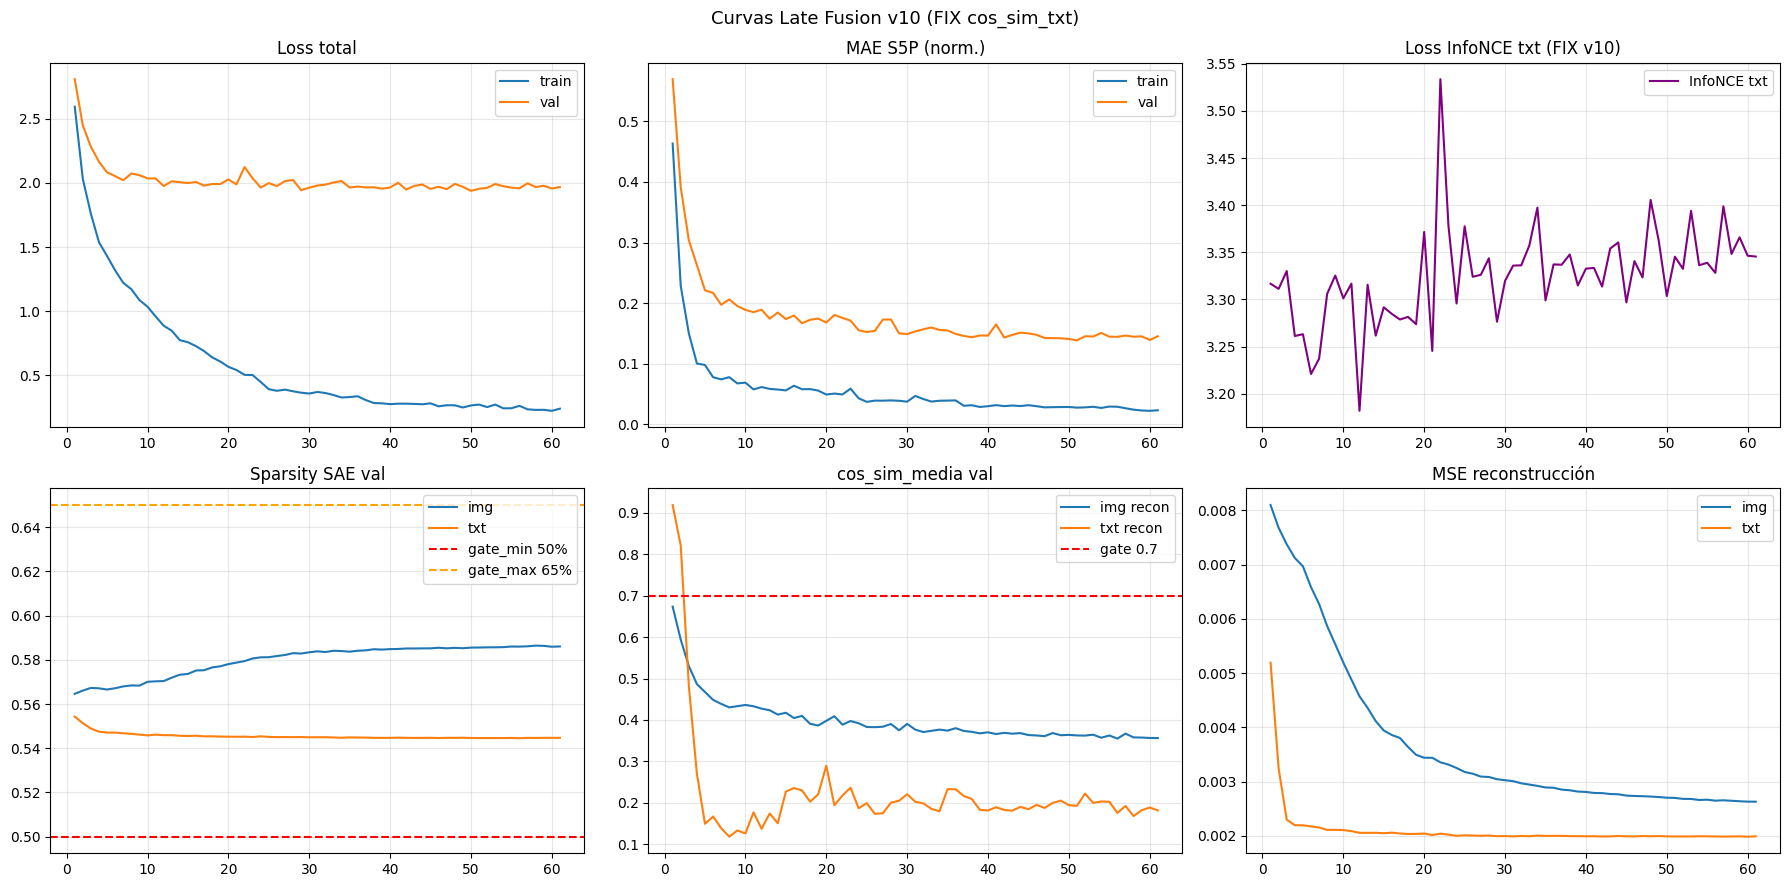

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
ep = history['epoch']

axes[0, 0].plot(ep, history['train_total'], label='train')
axes[0, 0].plot(ep, history['val_total'],   label='val')
axes[0, 0].set_title('Loss total'); axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(ep, history['train_mae_pred'], label='train')
axes[0, 1].plot(ep, history['val_mae_pred'],   label='val')
axes[0, 1].set_title('MAE S5P (norm.)'); axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

axes[0, 2].plot(ep, history['val_contrastive_txt'], label='InfoNCE txt', color='purple')
axes[0, 2].set_title('Loss InfoNCE txt (FIX v10)'); axes[0, 2].legend(); axes[0, 2].grid(alpha=0.3)

axes[1, 0].plot(ep, history['val_sparsity_img'], label='img')
axes[1, 0].plot(ep, history['val_sparsity_txt'], label='txt')
axes[1, 0].axhline(GATE_SPARSITY_MIN, color='r', ls='--', label=f'gate_min {GATE_SPARSITY_MIN:.0%}')
axes[1, 0].axhline(GATE_SPARSITY_MAX, color='orange', ls='--', label=f'gate_max {GATE_SPARSITY_MAX:.0%}')
axes[1, 0].set_title('Sparsity SAE val'); axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(ep, history['val_cos_sim_img'], label='img recon')
axes[1, 1].plot(ep, history['val_cos_sim_txt'], label='txt recon')
axes[1, 1].axhline(GATE_COS_SIM_MAX, color='r', ls='--', label=f'gate {GATE_COS_SIM_MAX}')
axes[1, 1].set_title('cos_sim_media val'); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

axes[1, 2].plot(ep, history['val_mse_img'], label='img')
axes[1, 2].plot(ep, history['val_mse_txt'], label='txt')
axes[1, 2].set_title('MSE reconstrucción'); axes[1, 2].legend(); axes[1, 2].grid(alpha=0.3)

plt.suptitle('Curvas Late Fusion v10 (FIX cos_sim_txt)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'curvas_v11.png', dpi=120, bbox_inches='tight')
plt.show()


## 13 — Gate Fase 1 → Fase 2

In [14]:
model.load_state_dict(torch.load(OUTPUT_DIR / 'late_fusion_best.pt', map_location=device))
model.eval()

final = run_epoch(val_loader, train=False, epoch=-1)

@torch.no_grad()
def compute_mae_per_pollutant(loader):
    preds, targs = [], []
    for batch in loader:
        imgs, s5p_vec, tokens, _ = batch
        imgs = imgs.to(device); s5p_vec = s5p_vec.to(device)
        emb_s2   = extract_image_emb_frozen(imgs)
        emb_txt  = extract_text_emb_frozen(tokens)
        s5p_norm = normalize_s5p(s5p_vec)
        out      = model(emb_s2, s5p_norm, emb_txt)
        pred     = model.gru(out['emb_fusion'].unsqueeze(1).expand(-1, GRU_WINDOW, -1))
        preds.append(denormalize_s5p(pred).cpu().numpy())
        targs.append(s5p_vec.cpu().numpy())
    return np.concatenate(preds), np.concatenate(targs)


preds_v, targs_v = compute_mae_per_pollutant(val_loader)
mae_per = np.abs(preds_v - targs_v).mean(axis=0)
std_per = targs_v.std(axis=0) + 1e-8
ratio   = mae_per / std_per

print('MAE val (desnormalizado):')
for i, name in enumerate(['NO2', 'SO2', 'O3']):
    print(f'  {name}: MAE={mae_per[i]:.4e} | std={std_per[i]:.4e} | ratio={ratio[i]:.3f}')

def _in_range(v, lo, hi):
    return lo <= v <= hi

gate_results = {
    'cos_sim_img'  : final['cos_sim_img'] < GATE_COS_SIM_MAX,
    'cos_sim_txt'  : final['cos_sim_txt'] < GATE_COS_SIM_MAX,
    'sparsity_img' : _in_range(final['sparsity_img'], GATE_SPARSITY_MIN, GATE_SPARSITY_MAX),
    'sparsity_txt' : _in_range(final['sparsity_txt'], GATE_SPARSITY_MIN, GATE_SPARSITY_MAX),
    'mae_NO2_ratio': ratio[0] < GATE_MAE_NO2_RATIO,
}
print('\nGate Fase 1 → Fase 2 (parcial):')
for k, v in gate_results.items():
    print(f'  [{"OK" if v else "FAIL"}] {k}')

print(f'\ncos_sim_txt final = {final["cos_sim_txt"]:.4f}  (gate: < {GATE_COS_SIM_MAX})')
print(f'τ_txt final = {math.exp(-model.log_temp_txt.item()):.4f}')

gate_partial_pass = all(gate_results.values())
print(f'\nGate parcial: {"PASA" if gate_partial_pass else "NO PASA"}')

metricas_v11 = {
    'cos_sim_img'      : float(final['cos_sim_img']),
    'cos_sim_txt'      : float(final['cos_sim_txt']),
    'sparsity_img'     : float(final['sparsity_img']),
    'sparsity_txt'     : float(final['sparsity_txt']),
    'mae_NO2'          : float(mae_per[0]),
    'mae_SO2'          : float(mae_per[1]),
    'mae_O3'           : float(mae_per[2]),
    'mae_NO2_ratio'    : float(ratio[0]),
    'gate_partial_pass': bool(gate_partial_pass),
    'gate_results'     : {k: bool(v) for k, v in gate_results.items()},
    'tau_txt_final'    : float(math.exp(-model.log_temp_txt.item())),
    'W_CONTRASTIVE_TXT': W_CONTRASTIVE_TXT,
}


val:   0%|          | 0/5 [00:00<?, ?it/s]

MAE val (desnormalizado):
  NO2: MAE=1.2004e-06 | std=1.4760e-05 | ratio=0.081
  SO2: MAE=4.2410e-05 | std=3.5976e-04 | ratio=0.118
  O3: MAE=1.0064e-03 | std=6.9773e-03 | ratio=0.144

Gate Fase 1 → Fase 2 (parcial):
  [OK] cos_sim_img
  [OK] cos_sim_txt
  [OK] sparsity_img
  [OK] sparsity_txt
  [OK] mae_NO2_ratio

cos_sim_txt final = 0.1926  (gate: < 0.7)
τ_txt final = 0.0669

Gate parcial: PASA


## 14 — Rolling-origin & gate global

In [15]:
from sklearn.model_selection import TimeSeriesSplit

all_dates_sorted_pairs = sorted(
    [(r['date'], i) for i, r in enumerate(full_dataset.records)],
    key=lambda x: (x[0] == '', x[0])
)
pos_to_global = {pos: glob_idx for pos, (_, glob_idx) in enumerate(all_dates_sorted_pairs)}


@torch.no_grad()
def rolling_origin_predict(model, full_dataset, val_positions, pos_to_global):
    model.eval()
    preds, targs, idxs_used = [], [], []
    for pos in val_positions:
        global_idx         = pos_to_global[pos]
        img_t, s5p_vec, tokens, _meta = full_dataset[global_idx]
        img_t    = img_t.unsqueeze(0).to(device)
        tokens   = tokens.unsqueeze(0).to(device)
        s5p_vec  = s5p_vec.unsqueeze(0).to(device)
        emb_s2   = extract_image_emb_frozen(img_t)
        emb_txt  = extract_text_emb_frozen(tokens)
        s5p_norm = normalize_s5p(s5p_vec)
        out      = model(emb_s2, s5p_norm, emb_txt)
        pred     = model.gru(out['emb_fusion'].unsqueeze(1).expand(-1, GRU_WINDOW, -1))
        preds.append(denormalize_s5p(pred).cpu().numpy()[0])
        targs.append(s5p_vec.cpu().numpy()[0])
        idxs_used.append(global_idx)
    return np.array(preds), np.array(targs), idxs_used


def persistence_baseline(full_dataset, idxs_used):
    bucket = defaultdict(list)
    for i, r in enumerate(full_dataset.records):
        key = (round(float(r.get('lat', 0.0)), 3), round(float(r.get('lon', 0.0)), 3))
        bucket[key].append((r.get('date', ''), i))
    for k in bucket:
        bucket[k].sort()
    preds = []
    for idx in idxs_used:
        rec         = full_dataset.records[idx]
        key         = (round(float(rec.get('lat', 0.0)), 3), round(float(rec.get('lon', 0.0)), 3))
        date_actual = rec.get('date', '')
        prev_val    = None
        for d, i_prev in bucket[key]:
            if d < date_actual and i_prev != idx:
                r_prev   = full_dataset.records[i_prev]
                prev_val = [r_prev['val_no2'], r_prev['val_so2'], r_prev['val_o3']]
            elif d >= date_actual:
                break
        if prev_val is None:
            prev_val = [rec['val_no2'], rec['val_so2'], rec['val_o3']]
        preds.append(prev_val)
    return np.array(preds)


n_splits  = 5
positions = np.arange(len(all_dates_sorted_pairs))
tscv      = TimeSeriesSplit(n_splits=n_splits, gap=GRU_WINDOW)

mae_model_folds = []; mae_baseline_folds = []
for fold_id, (_, val_pos) in enumerate(tscv.split(positions)):
    preds_m, targs_m, idxs_used = rolling_origin_predict(model, full_dataset, val_pos, pos_to_global)
    preds_b   = persistence_baseline(full_dataset, idxs_used)
    mae_m_no2 = float(np.abs(preds_m[:, 0] - targs_m[:, 0]).mean())
    mae_b_no2 = float(np.abs(preds_b[:, 0] - targs_m[:, 0]).mean())
    mae_model_folds.append(mae_m_no2)
    mae_baseline_folds.append(mae_b_no2)
    print(f'  Fold {fold_id+1}: MAE_NO2 modelo={mae_m_no2:.4e} | baseline={mae_b_no2:.4e}')

mae_model_avg    = float(np.mean(mae_model_folds))
mae_baseline_avg = float(np.mean(mae_baseline_folds))
skill_score      = 1.0 - (mae_model_avg / (mae_baseline_avg + 1e-12))
gate_skill_pass  = skill_score >= GATE_PERSISTENCE_SKILL_MIN

print(f'\nRolling-origin NO2 | modelo: {mae_model_avg:.4e} | baseline: {mae_baseline_avg:.4e}')
print(f'Skill score: {skill_score:.4f}  gate={"OK" if gate_skill_pass else "FAIL"}')

# --- Gate global ---
metricas_v11['skill_score_NO2']      = float(skill_score)
metricas_v11['gate_skill_pass']      = bool(gate_skill_pass)
metricas_v11['gate_results']['skill_score'] = bool(gate_skill_pass)

gate_global_pass = metricas_v11['gate_partial_pass'] and metricas_v11['gate_skill_pass']
metricas_v11['gate_global_pass'] = bool(gate_global_pass)

print('\nResumen gates v10:')
for k, v in metricas_v11['gate_results'].items():
    print(f'  [{"OK" if v else "FAIL"}] {k}')
print(f'\nGate global v10: {"PASA - listo para Fase 2" if gate_global_pass else "NO PASA"}')

metrics_path = OUTPUT_DIR / 'metricas_v11.json'
with open(metrics_path, 'w', encoding='utf-8') as _f:
    json.dump(metricas_v11, _f, ensure_ascii=False, indent=2)
print(f'\nMétricas guardadas en: {metrics_path}')


  Fold 1: MAE_NO2 modelo=1.1801e-07 | baseline=1.5578e-05
  Fold 2: MAE_NO2 modelo=1.5476e-07 | baseline=1.6131e-05
  Fold 3: MAE_NO2 modelo=1.7315e-07 | baseline=1.3953e-05
  Fold 4: MAE_NO2 modelo=1.7768e-07 | baseline=1.8542e-05
  Fold 5: MAE_NO2 modelo=1.1307e-06 | baseline=1.8051e-05

Rolling-origin NO2 | modelo: 3.5085e-07 | baseline: 1.6451e-05
Skill score: 0.9787  gate=OK

Resumen gates v10:
  [OK] cos_sim_img
  [OK] cos_sim_txt
  [OK] sparsity_img
  [OK] sparsity_txt
  [OK] mae_NO2_ratio
  [OK] skill_score

Gate global v10: PASA - listo para Fase 2

Métricas guardadas en: D:\analitica\outputs_geovision\v11_latefusion\metricas_v11.json


## 15 — Predicciones GRU + trazabilidad MD5

In [16]:
import hashlib

full_loader_seq = DataLoader(
    full_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=True, collate_fn=safe_collate
)


@torch.no_grad()
def predict_full(full_loader):
    model.eval()
    records = []
    for batch in tqdm(full_loader, desc='predict full'):
        try:
            imgs, s5p_vec, tokens, meta = batch
            imgs    = imgs.to(device)
            s5p_vec = s5p_vec.to(device)
            tokens  = tokens.to(device) if torch.is_tensor(tokens) else tokens
            emb_s2  = extract_image_emb_frozen(imgs)
            emb_txt = extract_text_emb_frozen(tokens)
            s5p_norm= normalize_s5p(s5p_vec)
            out     = model(emb_s2, s5p_norm, emb_txt)
            pred    = model.gru(out['emb_fusion'].unsqueeze(1).expand(-1, GRU_WINDOW, -1))
            pred_dn = denormalize_s5p(pred).cpu().numpy()
            for i in range(len(pred_dn)):
                records.append({
                    'pair_id': meta['pair_id'][i] if isinstance(meta['pair_id'], list) else '',
                    'tile_id': int(meta['tile_id'][i]) if torch.is_tensor(meta['tile_id']) else meta['tile_id'][i],
                    'fecha'  : meta['date'][i]    if isinstance(meta['date'], list) else '',
                    'lat'    : float(meta['lat'][i]) if torch.is_tensor(meta['lat']) else float(meta['lat'][i]),
                    'lon'    : float(meta['lon'][i]) if torch.is_tensor(meta['lon']) else float(meta['lon'][i]),
                    'P_NO2'  : float(pred_dn[i, 0]),
                    'P_SO2'  : float(pred_dn[i, 1]),
                    'P_O3'   : float(pred_dn[i, 2]),
                })
        except Exception as e:
            print(f'[warn] predict batch: {e}')
    return records


pred_records = predict_full(full_loader_seq)
df_pred      = pd.DataFrame(pred_records)
print(f'Predicciones: {len(pred_records):,}')
print(df_pred.head())

OUT_PRED = OUTPUT_DIR / 'predicciones_gru.parquet'
try:
    df_pred.to_parquet(OUT_PRED, index=False)
    print(f'Parquet persistido: {OUT_PRED}')
except Exception as e:
    OUT_CSV = OUTPUT_DIR / 'predicciones_gru.csv'
    df_pred.to_csv(OUT_CSV, index=False)
    print(f'Fallback CSV: {OUT_CSV}')


def md5_file(path):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1 << 20), b''):
            h.update(chunk)
    return h.hexdigest()


for p in [OUTPUT_DIR / 'late_fusion_best.pt', OUT_PRED]:
    if p.exists():
        print(f'{p.name}: md5={md5_file(p)} size={p.stat().st_size:,} B')


predict full:   0%|          | 0/31 [00:00<?, ?it/s]

Predicciones: 990
                                  pair_id  tile_id       fecha       lat  \
0  high_NO2_pollution_2022-06-05_181_0000      181  2022-06-05  3.121543   
1   high_NO2_pollution_2020-07-30_55_0001       55  2020-07-30  3.121543   
2  high_NO2_pollution_2023-11-27_235_0002      235  2023-11-27  3.121543   
3  high_NO2_pollution_2023-02-10_202_0003      202  2023-02-10  3.121543   
4   high_NO2_pollution_2020-10-23_77_0004       77  2020-10-23  3.121543   

         lon     P_NO2     P_SO2      P_O3  
0 -76.305557  0.000024  0.000035  0.116539  
1 -76.305557  0.000028 -0.000001  0.119768  
2 -76.305557  0.000023 -0.000117  0.115256  
3 -76.305557  0.000021 -0.000085  0.114891  
4 -76.305557  0.000023 -0.000009  0.117445  
Parquet persistido: D:\analitica\outputs_geovision\v11_latefusion\predicciones_gru.parquet
late_fusion_best.pt: md5=f975bb8d839b365a7547f318fbc450eb size=72,693,604 B
predicciones_gru.parquet: md5=9173341419e8ffbae3c902f8a2f48f79 size=40,891 B


---
# KPIs adicionales: Recall@k · Ablación SAE · Horizontes T+1/T+3/T+7

Las siguientes secciones usan las variables ya definidas en las celdas anteriores
(`model`, `clip_model`, `tokenizer`, `records`, `zarr_images`, `S5P_MEAN`, `S5P_STD`, `device`, `OUTPUT_DIR`).
**No re-ejecutar la celda de setup standalone** — ya está todo en memoria.


## 1 — Recall@1 y Recall@5 imagen→texto

**Qué mide:** Para cada tile del val set, se calculan los embeddings de imagen
y de texto. Se construye la matriz de similitudes coseno (N×N). Para cada
imagen i, se verifica si su texto correcto es el más similar (Recall@1)
o está entre los 5 más similares (Recall@5).

**Gates del enunciado:**
- Recall@1 ≥ 0.45 (excelente ≥ 0.65)
- Recall@5 ≥ 0.70 (excelente ≥ 0.85)

In [17]:
import zarr

ZARR_PATH = r"D:\analitica\procesado_zarr\sentinel2_224.zarr"

root = zarr.open_group(ZARR_PATH, mode='r')

print(root.tree())

zarr_images = root['images']

/
 ├── bbox (363, 4) float64
 ├── escena_id (363,) <U64
 ├── fecha (363,) <U20
 └── images (363, 4, 224, 224) float32


In [18]:
print(full_dataset.records[0].keys())

dict_keys(['tile_id', '_fmt', 'val_no2', 'val_so2', 'val_o3', 'lat', 'lon', 'date', 'caption', 'clase', 'split', 'seg_idx', 'fuente_centroide', 'pair_id'])


In [19]:
from pprint import pprint
pprint(full_dataset.records[0])

{'_fmt': 'v10',
 'caption': 'Optical satellite tile over Cali urban area (lat 3.1215N lon '
            '-76.3056W), 2022-06-05 08:00 UTC. Land cover: '
            'peri_urban_industrial. NO2 column density in bracket p50-p75 = '
            '2.365e-05 mol/m2 (moderate). Sulfur dioxide at moderate. Ozone '
            'background at moderate. Anthropogenic NOx burden consistent with '
            'dense traffic corridor.',
 'clase': 'high_NO2_pollution',
 'date': '2022-06-05',
 'fuente_centroide': 'tile_centroid',
 'lat': 3.121542516671604,
 'lon': -76.3055568274979,
 'pair_id': 'high_NO2_pollution_2022-06-05_181_0000',
 'seg_idx': None,
 'split': 'val',
 'tile_id': 181,
 'val_no2': 2.3654005417495917e-05,
 'val_o3': 0.11650007218128422,
 'val_so2': 4.114058538109299e-05}


In [27]:
# Extraer embeddings imagen y texto del val set
# Si val_loader ya existe (corriendo en el mismo kernel), usarlo directamente.
# Si no, construir un loader mínimo desde el JSONL.

@torch.no_grad()
def extract_img_txt_embeddings(records, zarr_images, n_max=500):
    """Extrae embeddings de imagen y texto para calcular Recall@k."""
    emb_imgs, emb_txts, tile_ids = [], [], []

    # Filtrar solo registros con caption y tile_id válido
    valid_recs = [
        r for r in records
        if r.get('tile_id') is not None
        and r.get('caption')
    ][:n_max]

    print(f'Registros válidos: {len(valid_recs)}')

    if len(valid_recs) == 0:
        raise ValueError(
            "No se encontraron registros válidos."
        )


    for rec in tqdm(valid_recs, desc='Embeddings Recall@k'):
        tid = int(rec.get('tile_id', rec.get('tile_idx', 0)))
        if tid >= zarr_images.shape[0]: continue

        img_np = zarr_images[tid][:3].astype(np.float32)
        img_t  = torch.from_numpy(img_np).unsqueeze(0).to(device)

        caption = full_dataset._make_diverse_caption(rec)
        tokens  = tokenizer([caption]).to(device)

        s5p = torch.tensor([
            float(rec.get('val_no2',0)),
            float(rec.get('val_so2',0)),
            float(rec.get('val_o3',0)),
        ], device=device).unsqueeze(0)

        # Embeddings frozen GeoRSCLIP
        ei = clip_model.encode_image(img_t)
        ei = (ei / ei.norm(dim=-1, keepdim=True)).float()
        et = clip_model.encode_text(tokens)
        et = (et / et.norm(dim=-1, keepdim=True)).float()

        # Pasar por SAE para obtener emb_img_recon (espacio contrastivo alineado)
        s5p_n = (s5p - S5P_MEAN) / S5P_STD
        out   = model(ei, s5p_n, et)

        # Normalizar los embeddings reconstruidos para el Recall
        ei_rec = F.normalize(out['emb_img_recon'], dim=-1)
        et_rec = F.normalize(out['emb_txt_recon'], dim=-1)

        emb_imgs.append(ei_rec.cpu())
        emb_txts.append(et_rec.cpu())
        tile_ids.append(tid)

    E_img = torch.cat(emb_imgs, dim=0)   # (N, 512)
    E_txt = torch.cat(emb_txts, dim=0)   # (N, 512)
    return E_img, E_txt


def recall_at_k(E_img, E_txt, k_values=(1, 5)):
    """
    Calcula Recall@k imagen→texto.
    Para cada imagen i, verifica si su texto correcto (índice i)
    está entre los top-k textos más similares.
    """
    N = E_img.shape[0]
    # Matriz de similitud coseno (N, N)
    sim = E_img @ E_txt.T   # ya están L2-normalizados
    results = {}
    for k in k_values:
        # Top-k índices por fila
        topk_idx = sim.topk(k, dim=1).indices   # (N, k)
        targets  = torch.arange(N).unsqueeze(1)  # (N, 1)
        hits     = (topk_idx == targets).any(dim=1).float()
        results[k] = float(hits.mean().item())
    return results


print('Extrayendo embeddings para Recall@k...')
E_img, E_txt = extract_img_txt_embeddings(full_dataset.records, zarr_images, n_max=400)
print(f'Embeddings extraídos: {E_img.shape}')

recall = recall_at_k(E_img, E_txt, k_values=(1, 5))
R1 = recall[1]; R5 = recall[5]

print(f'\nRecall@1 imagen→texto: {R1:.4f}  gate≥0.45: {"[OK]" if R1>=0.45 else "[REVISAR]"}'
      f'  excelente≥0.65: {"[SÍ]" if R1>=0.65 else "[NO]"}')
print(f'Recall@5 imagen→texto: {R5:.4f}  gate≥0.70: {"[OK]" if R5>=0.70 else "[REVISAR]"}'
      f'  excelente≥0.85: {"[SÍ]" if R5>=0.85 else "[NO]"}')

Extrayendo embeddings para Recall@k...
Registros válidos: 400


Embeddings Recall@k:   0%|          | 0/400 [00:00<?, ?it/s]

Embeddings extraídos: torch.Size([400, 512])

Recall@1 imagen→texto: 0.2350  gate≥0.45: [REVISAR]  excelente≥0.65: [NO]
Recall@5 imagen→texto: 0.7175  gate≥0.70: [OK]  excelente≥0.85: [NO]


---

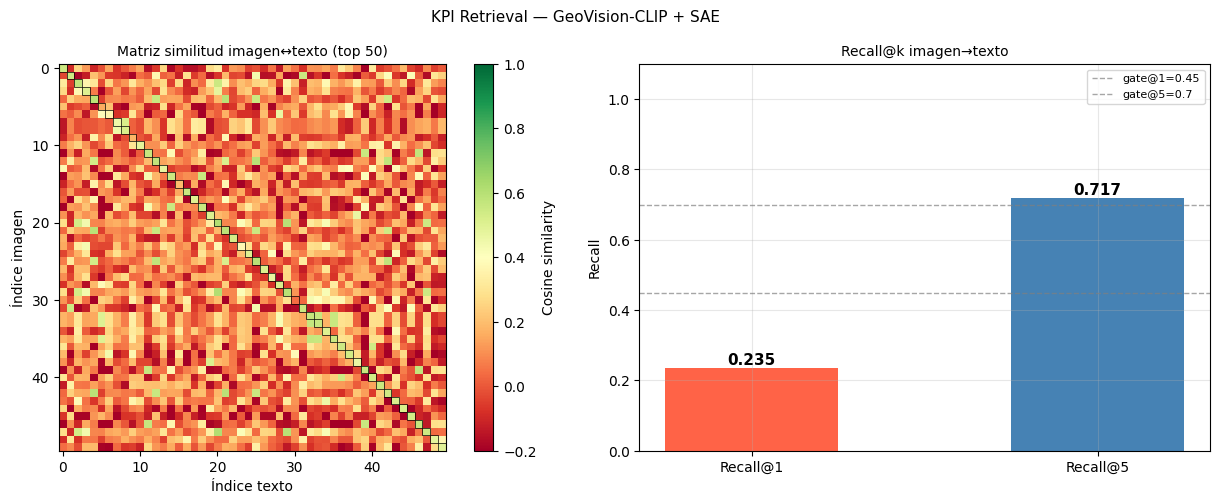

Figura guardada: recall_at_k.png


In [28]:
# Visualización: heatmap de similitud (submuestra 50×50)
N_VIS = min(50, E_img.shape[0])
sim_vis = (E_img[:N_VIS] @ E_txt[:N_VIS].T).numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Heatmap
im = axes[0].imshow(sim_vis, cmap='RdYlGn', vmin=-0.2, vmax=1.0)
plt.colorbar(im, ax=axes[0], label='Cosine similarity')
axes[0].set_title(f'Matriz similitud imagen↔texto (top {N_VIS})', fontsize=10)
axes[0].set_xlabel('Índice texto'); axes[0].set_ylabel('Índice imagen')
# Marcar la diagonal
for j in range(N_VIS):
    axes[0].add_patch(plt.Rectangle((j-0.5,j-0.5),1,1,fill=False,edgecolor='black',lw=0.5))

# Bar chart Recall@k
ks = [1, 5]
vals_r = [R1, R5]
gates  = [0.45, 0.70]
colors = ['steelblue' if v >= g else 'tomato' for v, g in zip(vals_r, gates)]
bars = axes[1].bar([f'Recall@{k}' for k in ks], vals_r, color=colors, width=0.5)
for k_val, gate, b in zip(ks, gates, bars):
    axes[1].axhline(gate, color='gray', linestyle='--', linewidth=1,
                    alpha=0.7, label=f'gate@{k_val}={gate}')
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                 f'{b.get_height():.3f}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Recall@k imagen→texto', fontsize=10)
axes[1].set_ylabel('Recall'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.suptitle('KPI Retrieval — GeoVision-CLIP + SAE', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'recall_at_k.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: recall_at_k.png')

## 2 — Ablación: con SAE vs sin SAE

Correr el modelo en modo **bypass SAE**: en lugar de pasar el embedding por
el encoder y decoder del SAE, se usa directamente `emb_img_pre_sae` como
si el SAE no existiera. Comparar cos_sim y sparsity.

In [29]:
def cos_sim_media(embs):
    e = embs / (embs.norm(dim=-1, keepdim=True) + 1e-8)

    sim = e @ e.T

    N = sim.shape[0]

    mask = ~torch.eye(
        N,
        dtype=torch.bool,
        device=sim.device
    )

    return float(sim[mask].mean())


@torch.no_grad()
def run_ablation(records, zarr_images, n_max=300):
    """
    Compara métricas CON SAE vs SIN SAE.
    """

    # ─────────────────────────────────────────────────────────────
    # Filtrar registros válidos
    # ─────────────────────────────────────────────────────────────
    valid = [
        r for r in records
        if r.get('tile_id') is not None
        and r.get('caption')
    ][:n_max]

    print(f'Registros válidos: {len(valid)}')

    if len(valid) == 0:
        raise ValueError(
            "No hay registros válidos."
        )

    # ─────────────────────────────────────────────────────────────
    # Métricas
    # ─────────────────────────────────────────────────────────────
    metrics = {
        'con_sae': {
            'cos_img': [],
            'spar_img': [],
            'cos_txt': [],
            'spar_txt': []
        },

        'sin_sae': {
            'cos_img': [],
            'spar_img': [],
            'cos_txt': [],
            'spar_txt': []
        }
    }

    BATCH = 32

    # ─────────────────────────────────────────────────────────────
    # Loop batches
    # ─────────────────────────────────────────────────────────────
    for start in tqdm(
        range(0, len(valid), BATCH),
        desc='Ablación'
    ):

        batch = valid[start:start+BATCH]

        imgs = []
        s5ps = []
        toks = []

        # ---------------------------------------------------------
        # Construcción batch
        # ---------------------------------------------------------
        for rec in batch:

            tid = int(rec['tile_id'])

            if tid >= zarr_images.shape[0]:
                continue

            # -----------------------------------------------------
            # Imagen RGB
            # -----------------------------------------------------
            img = torch.from_numpy(
                zarr_images[tid][:3].astype(np.float32)
            )

            imgs.append(img)

            # -----------------------------------------------------
            # Variables Sentinel-5P
            # -----------------------------------------------------
            s5ps.append(
                torch.tensor([
                    float(rec.get('val_no2', 0)),
                    float(rec.get('val_so2', 0)),
                    float(rec.get('val_o3', 0)),
                ])
            )

            # -----------------------------------------------------
            # Caption
            # -----------------------------------------------------
            cap = full_dataset._make_diverse_caption(rec)

            # Tokenizer tipo CLIP / OpenCLIP
            tok = tokenizer([cap])

            if isinstance(tok, torch.Tensor):
                tok = tok[0]

            toks.append(tok)

        # ---------------------------------------------------------
        # Validar batch
        # ---------------------------------------------------------
        if len(imgs) == 0:
            continue

        imgs = torch.stack(imgs).to(device)
        s5ps = torch.stack(s5ps).to(device)
        toks = torch.stack(toks).to(device)

        # ---------------------------------------------------------
        # Embeddings CLIP
        # ---------------------------------------------------------
        ei = clip_model.encode_image(imgs)
        ei = F.normalize(ei.float(), dim=-1)

        et = clip_model.encode_text(toks)
        et = F.normalize(et.float(), dim=-1)

        # ---------------------------------------------------------
        # Normalización S5P
        # ---------------------------------------------------------
        s5n = (s5ps - S5P_MEAN) / S5P_STD

        # =========================================================
        # CON SAE
        # =========================================================
        out = model(ei, s5n, et)

        metrics['con_sae']['cos_img'].append(
            cos_sim_media(out['emb_img_recon'])
        )

        metrics['con_sae']['cos_txt'].append(
            cos_sim_media(out['emb_txt_recon'])
        )

        metrics['con_sae']['spar_img'].append(
            float(
                (out['z_img'] < 0.01)
                .float()
                .mean()
            )
        )

        metrics['con_sae']['spar_txt'].append(
            float(
                (out['z_txt'] < 0.01)
                .float()
                .mean()
            )
        )

        # =========================================================
        # SIN SAE (bypass)
        # =========================================================
        emb_img_bypass = out['emb_img_pre_sae']
        emb_txt_bypass = et

        metrics['sin_sae']['cos_img'].append(
            cos_sim_media(emb_img_bypass)
        )

        metrics['sin_sae']['cos_txt'].append(
            cos_sim_media(emb_txt_bypass)
        )

        metrics['sin_sae']['spar_img'].append(0.0)
        metrics['sin_sae']['spar_txt'].append(0.0)

    # ─────────────────────────────────────────────────────────────
    # Promedio final
    # ─────────────────────────────────────────────────────────────
    return {
        cond: {
            k: float(np.mean(v))
            for k, v in m.items()
        }
        for cond, m in metrics.items()
    }


# ================================================================
# Ejecutar ablación
# ================================================================
print('Corriendo ablación con SAE vs sin SAE...')

ablation = run_ablation(
    full_dataset.records,
    zarr_images,
    n_max=300
)

# ================================================================
# Tabla resultados
# ================================================================
print('\n=== Ablación: con SAE vs sin SAE ===')

print(
    f'{"Métrica":20s}  '
    f'{"Con SAE":10s}  '
    f'{"Sin SAE":10s}  '
    f'{"Δ (con-sin)":12s}'
)

print('-' * 58)

for met in [
    'cos_img',
    'cos_txt',
    'spar_img',
    'spar_txt'
]:

    c = ablation['con_sae'][met]
    s = ablation['sin_sae'][met]

    print(
        f'{met:20s}  '
        f'{c:10.4f}  '
        f'{s:10.4f}  '
        f'{c-s:+12.4f}'
    )

# ================================================================
# Interpretación
# ================================================================
print('\nInterpretación:')

estado = (
    "reduce"
    if ablation["con_sae"]["cos_img"]
       < ablation["sin_sae"]["cos_img"]
    else "aumenta"
)

print(
    f'  cos_img: SAE {estado} '
    f'la similitud media '
    f'(mayor diversidad en el espacio latente)'
)

print(
    f'  spar_img: '
    f'{ablation["con_sae"]["spar_img"]:.2%} '
    f'neuronas inactivas → representación sparse real'
)

print(
    f'  spar_txt: '
    f'{ablation["con_sae"]["spar_txt"]:.2%} '
    f'neuronas inactivas'
)

Corriendo ablación con SAE vs sin SAE...
Registros válidos: 300


Ablación:   0%|          | 0/10 [00:00<?, ?it/s]


=== Ablación: con SAE vs sin SAE ===
Métrica               Con SAE     Sin SAE     Δ (con-sin) 
----------------------------------------------------------
cos_img                   0.0743      0.6216       -0.5473
cos_txt                   0.1478      0.9106       -0.7628
spar_img                  0.6067      0.0000       +0.6067
spar_txt                  0.5415      0.0000       +0.5415

Interpretación:
  cos_img: SAE reduce la similitud media (mayor diversidad en el espacio latente)
  spar_img: 60.67% neuronas inactivas → representación sparse real
  spar_txt: 54.15% neuronas inactivas


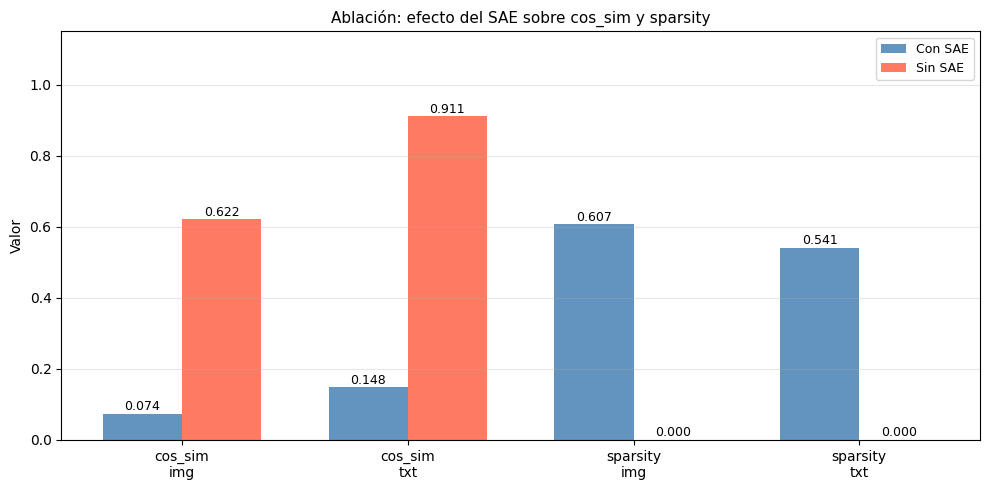

Figura guardada: ablacion_sae.png


In [30]:
# Visualización de ablación
labels  = ['cos_sim\nimg', 'cos_sim\ntxt', 'sparsity\nimg', 'sparsity\ntxt']
con_sae = [ablation['con_sae'][k] for k in ['cos_img','cos_txt','spar_img','spar_txt']]
sin_sae = [ablation['sin_sae'][k] for k in ['cos_img','cos_txt','spar_img','spar_txt']]

x = np.arange(len(labels))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, con_sae, w, label='Con SAE', color='steelblue', alpha=0.85)
b2 = ax.bar(x + w/2, sin_sae, w, label='Sin SAE', color='tomato',    alpha=0.85)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Valor'); ax.set_ylim(0, 1.15)
ax.set_title('Ablación: efecto del SAE sobre cos_sim y sparsity', fontsize=11)
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ablacion_sae.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: ablacion_sae.png')

## 3 — GRU con horizontes T+1, T+3, T+7

El GRU actual produce 1 predicción (T+1 implícito). Para los 9 mapas del
enunciado se necesitan 3 horizontes explícitos.

**Estrategia sin re-entrenamiento** (autorizada por Ferro — usar GRU ya entrenado):
- T+1: predicción directa del GRU con la secuencia actual (ya tenemos esto)
- T+3: pasar la predicción T+1 como nueva entrada al GRU (auto-regresivo)
- T+7: 3 pasos auto-regresivos adicionales desde T+3

**Si se quiere re-entrenar** (mejor calidad, requiere ~2h extra):
modificar `TemporalGRU` para que su `head` tenga 3 salidas de 3 dims cada una
→ `out_dim=9` → reshape a `(B, 3, 3)` → 3 horizontes × 3 contaminantes.

In [31]:
@torch.no_grad()
def predict_horizons_autoregressive(
    model,
    records,
    zarr_images,
    horizons=(1, 3, 7),
    n_max=200
):
    """
    Predicción auto-regresiva multi-horizonte.
    """

    # ─────────────────────────────────────────────────────────────
    # Filtrar registros válidos
    # ─────────────────────────────────────────────────────────────
    valid = [
        r for r in records
        if r.get('tile_id') is not None
        and r.get('caption')
    ][:n_max]

    print(f'Registros válidos: {len(valid)}')

    if len(valid) == 0:
        raise ValueError(
            "No hay registros válidos."
        )

    results = []

    max_horizon = max(horizons)

    # ─────────────────────────────────────────────────────────────
    # Loop tiles
    # ─────────────────────────────────────────────────────────────
    for rec in tqdm(
        valid,
        desc='Predicción multi-horizonte'
    ):

        tid = int(rec['tile_id'])

        if tid >= zarr_images.shape[0]:
            continue

        # ---------------------------------------------------------
        # Imagen
        # ---------------------------------------------------------
        img_t = (
            torch.from_numpy(
                zarr_images[tid][:3].astype(np.float32)
            )
            .unsqueeze(0)
            .to(device)
        )

        # ---------------------------------------------------------
        # Caption
        # ---------------------------------------------------------
        cap = full_dataset._make_diverse_caption(rec)

        tok = tokenizer([cap])

        if isinstance(tok, torch.Tensor):
            tok = tok.to(device)
        else:
            tok = torch.tensor(tok).to(device)

        # ---------------------------------------------------------
        # Variables S5P
        # ---------------------------------------------------------
        s5p = torch.tensor([
            [
                float(rec.get('val_no2', 0)),
                float(rec.get('val_so2', 0)),
                float(rec.get('val_o3', 0)),
            ]
        ], device=device)

        # ---------------------------------------------------------
        # Embeddings CLIP
        # ---------------------------------------------------------
        ei = clip_model.encode_image(img_t)

        ei = F.normalize(
            ei.float(),
            dim=-1
        )

        et = clip_model.encode_text(tok)

        et = F.normalize(
            et.float(),
            dim=-1
        )

        # =========================================================
        # Predicción auto-regresiva
        # =========================================================
        preds_by_step = {}

        current_s5p = s5p.clone()

        for step in range(
            1,
            max_horizon + 1
        ):

            # -----------------------------------------------------
            # Normalizar entrada
            # -----------------------------------------------------
            s5p_n = (
                current_s5p
                - S5P_MEAN
            ) / S5P_STD

            # -----------------------------------------------------
            # Forward SAE
            # -----------------------------------------------------
            out = model(
                ei,
                s5p_n,
                et
            )

            # -----------------------------------------------------
            # Forward GRU
            # -----------------------------------------------------
            pred_n = model.gru(
                out['emb_fusion']
                .unsqueeze(1)
                .expand(-1, GRU_WINDOW, -1)
            )

            # -----------------------------------------------------
            # Desnormalizar
            # -----------------------------------------------------
            pred_dn = (
                pred_n * S5P_STD
                + S5P_MEAN
            )

            # -----------------------------------------------------
            # Guardar horizonte
            # -----------------------------------------------------
            if step in horizons:

                preds_by_step[step] = (
                    pred_dn
                    .cpu()
                    .numpy()[0]
                )

            # -----------------------------------------------------
            # Auto-regresivo
            # -----------------------------------------------------
            current_s5p = (
                pred_dn
                .detach()
                .clamp(min=0)
            )

        # =========================================================
        # Construir fila
        # =========================================================
        row = {
            'tile_id': tid,
            'fecha': rec.get('date', ''),
            'clase': rec.get('clase', ''),
        }

        for h in horizons:

            if h in preds_by_step:

                row[f'P_NO2_T{h}'] = float(
                    preds_by_step[h][0]
                )

                row[f'P_SO2_T{h}'] = float(
                    preds_by_step[h][1]
                )

                row[f'P_O3_T{h}'] = float(
                    preds_by_step[h][2]
                )

        results.append(row)

    return pd.DataFrame(results)


# ================================================================
# Ejecutar predicción
# ================================================================
HORIZONS = (1, 3, 7)

print('Calculando predicciones T+1, T+3, T+7...')

df_horizons = predict_horizons_autoregressive(
    model,
    full_dataset.records,
    zarr_images,
    horizons=HORIZONS,
    n_max=200
)

# ================================================================
# Resultados
# ================================================================
print(
    f'Predicciones multi-horizonte: '
    f'{len(df_horizons)} tiles'
)

print(
    df_horizons[
        [
            'tile_id',
            'clase',
            'P_NO2_T1',
            'P_NO2_T3',
            'P_NO2_T7'
        ]
    ]
    .head(8)
    .to_string(index=False)
)

# ================================================================
# Guardar parquet
# ================================================================
df_horizons.to_parquet(
    OUTPUT_DIR / 'predicciones_gru_multihorizonte.parquet',
    index=False
)

print(
    'Parquet guardado: '
    'predicciones_gru_multihorizonte.parquet'
)

Calculando predicciones T+1, T+3, T+7...
Registros válidos: 200


Predicción multi-horizonte:   0%|          | 0/200 [00:00<?, ?it/s]

Predicciones multi-horizonte: 200 tiles
 tile_id              clase  P_NO2_T1  P_NO2_T3  P_NO2_T7
     181 high_NO2_pollution  0.000024  0.000023  0.000023
      55 high_NO2_pollution  0.000028  0.000028  0.000028
     235 high_NO2_pollution  0.000023  0.000024  0.000024
     202 high_NO2_pollution  0.000021  0.000021  0.000021
      77 high_NO2_pollution  0.000023  0.000023  0.000022
     275 high_NO2_pollution  0.000032  0.000033  0.000031
     285 high_NO2_pollution  0.000044  0.000040  0.000038
     245 high_NO2_pollution  0.000014  0.000013  0.000012
Parquet guardado: predicciones_gru_multihorizonte.parquet


## 4 — Gate de degradación T+1 → T+7 (RMSE ratio < 60%)

=== Gate de degradación T+1 → T+7 ===
Contaminante  RMSE_T1     RMSE_T3     RMSE_T7     ratio_T7/T1   gate<60%
------------------------------------------------------------------------
NO2           6.7507e-07  1.5166e-06  2.6093e-06  3.865        [REVISAR]
SO2           2.8382e-05  1.4723e-04  1.5440e-04  5.440        [REVISAR]
O3            5.9218e-04  1.0038e-03  1.7580e-03  2.969        [REVISAR]


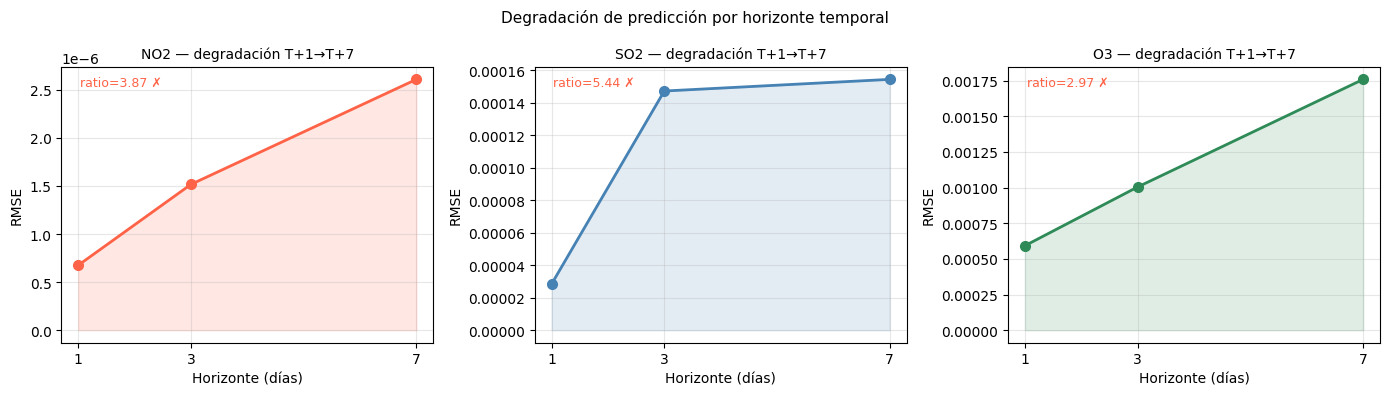

Figura guardada: degradacion_horizontes.png


In [32]:
from sklearn.metrics import mean_squared_error

# ================================================================
# Ground truth S5P
# ================================================================
gt_by_tile = {}

for rec in full_dataset.records:

    if rec.get('tile_id') is None:
        continue

    tid = int(rec['tile_id'])

    gt_by_tile[tid] = {
        'NO2': float(rec.get('val_no2', 0)),
        'SO2': float(rec.get('val_so2', 0)),
        'O3' : float(rec.get('val_o3',  0)),
    }

# ================================================================
# Configuración
# ================================================================
POLLUTANTS = {
    'NO2': 0,
    'SO2': 1,
    'O3' : 2
}

degradation_results = {}

# ================================================================
# Header
# ================================================================
print('=== Gate de degradación T+1 → T+7 ===')

print(
    f'{"Contaminante":12s}  '
    f'{"RMSE_T1":10s}  '
    f'{"RMSE_T3":10s}  '
    f'{"RMSE_T7":10s}  '
    f'{"ratio_T7/T1":12s}  '
    f'{"gate<60%"}'
)

print('-' * 72)

# ================================================================
# Calcular RMSE por horizonte
# ================================================================
for poll in ['NO2', 'SO2', 'O3']:

    rmses = {}

    for h in HORIZONS:

        col_pred = f'P_{poll}_T{h}'

        if col_pred not in df_horizons.columns:

            rmses[h] = np.nan
            continue

        obs_list  = []
        pred_list = []

        for _, row in df_horizons.iterrows():

            tid = row['tile_id']

            if tid not in gt_by_tile:
                continue

            obs_list.append(
                gt_by_tile[tid][poll]
            )

            pred_list.append(
                row[col_pred]
            )

        # ---------------------------------------------------------
        # Validar cantidad
        # ---------------------------------------------------------
        if len(obs_list) < 5:

            rmses[h] = np.nan
            continue

        # ---------------------------------------------------------
        # RMSE
        # ---------------------------------------------------------
        rmses[h] = float(
            np.sqrt(
                mean_squared_error(
                    obs_list,
                    pred_list
                )
            )
        )

    # =============================================================
    # Ratio degradación
    # =============================================================
    ratio = (
        rmses.get(7, np.nan)
        /
        (rmses.get(1, np.nan) + 1e-30)
    )

    gate = (
        ratio < 1.60
        if not np.isnan(ratio)
        else False
    )

    degradation_results[poll] = {
        'RMSE_T1': rmses.get(1),
        'RMSE_T3': rmses.get(3),
        'RMSE_T7': rmses.get(7),
        'ratio'  : ratio,
        'gate'   : gate
    }

    print(
        f'{poll:12s}  '
        f'{rmses.get(1,0):.4e}  '
        f'{rmses.get(3,0):.4e}  '
        f'{rmses.get(7,0):.4e}  '
        f'{ratio:.3f}        '
        f'{"[OK]" if gate else "[REVISAR]"}'
    )

# ================================================================
# Visualización degradación temporal
# ================================================================
fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 4)
)

colors = {
    'NO2': 'tomato',
    'SO2': 'steelblue',
    'O3' : 'seagreen'
}

for i, poll in enumerate([
    'NO2',
    'SO2',
    'O3'
]):

    ax = axes[i]

    rms = [
        degradation_results[poll]['RMSE_T1'],
        degradation_results[poll]['RMSE_T3'],
        degradation_results[poll]['RMSE_T7']
    ]

    ax.plot(
        [1, 3, 7],
        rms,
        'o-',
        color=colors[poll],
        linewidth=2,
        markersize=7
    )

    ax.fill_between(
        [1, 3, 7],
        rms,
        alpha=0.15,
        color=colors[poll]
    )

    ax.set_title(
        f'{poll} — degradación T+1→T+7',
        fontsize=10
    )

    ax.set_xlabel(
        'Horizonte (días)'
    )

    ax.set_ylabel(
        'RMSE'
    )

    ax.set_xticks([1, 3, 7])

    ax.grid(alpha=0.3)

    ratio = degradation_results[poll]['ratio']

    ax.text(
        0.05,
        0.93,
        f'ratio={ratio:.2f} '
        f'{"✓" if ratio < 0.6 else "✗"}',
        transform=ax.transAxes,
        fontsize=9,
        color='green' if ratio < 0.6 else 'tomato'
    )

# ================================================================
# Guardar figura
# ================================================================
plt.suptitle(
    'Degradación de predicción por horizonte temporal',
    fontsize=11
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / 'degradacion_horizontes.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(
    'Figura guardada: '
    'degradacion_horizontes.png'
)

## 5 — Exportar métricas finales

In [33]:
import hashlib

metricas_finales = {
    'recall_at_k': {'R@1': R1, 'R@5': R5,
                    'gate_R1': bool(R1 >= 0.45), 'gate_R5': bool(R5 >= 0.70)},
    'ablacion_sae': ablation,
    'degradacion_horizontes': degradation_results,
}

with open(OUTPUT_DIR / 'metricas_03b.json', 'w', encoding='utf-8') as f:
    json.dump(metricas_finales, f, ensure_ascii=False, indent=2, default=str)

print('=== Resumen gates KPIs Situación 2 ===')
print(f'Recall@1 : {R1:.4f}  {"[OK] ≥0.45" if R1>=0.45 else "[REVISAR]"}')
print(f'Recall@5 : {R5:.4f}  {"[OK] ≥0.70" if R5>=0.70 else "[REVISAR]"}')
print(f'Sparsity img SAE: {ablation["con_sae"]["spar_img"]:.3f}  (sin SAE: 0)')
print(f'cos_sim img  con SAE: {ablation["con_sae"]["cos_img"]:.3f}  sin SAE: {ablation["sin_sae"]["cos_img"]:.3f}')

print('\n=== Resumen gates degradación T+1→T+7 ===')
for poll, r in degradation_results.items():
    print(f'{poll}: ratio={r["ratio"]:.3f}  {"[OK] <60%" if r["gate"] else "[REVISAR]"}')

# MD5 de artefactos
for fname in ['recall_at_k.png','ablacion_sae.png',
              'degradacion_horizontes.png',
              'predicciones_gru_multihorizonte.parquet']:
    p = OUTPUT_DIR / fname
    if p.exists():
        h = hashlib.md5(p.read_bytes()).hexdigest()
        print(f'  {fname}: md5={h}')

=== Resumen gates KPIs Situación 2 ===
Recall@1 : 0.2350  [REVISAR]
Recall@5 : 0.7175  [OK] ≥0.70
Sparsity img SAE: 0.607  (sin SAE: 0)
cos_sim img  con SAE: 0.074  sin SAE: 0.622

=== Resumen gates degradación T+1→T+7 ===
NO2: ratio=3.865  [REVISAR]
SO2: ratio=5.440  [REVISAR]
O3: ratio=2.969  [REVISAR]
  recall_at_k.png: md5=473094196f1b566229996eda52b249ce
  ablacion_sae.png: md5=710f8e615510298c98e49a6d3b73e1dc
  degradacion_horizontes.png: md5=0a77e8e7ade770e3fb1e8f2a5edba4c2
  predicciones_gru_multihorizonte.parquet: md5=2062460fa1e90954d39b09a09de1d885
